# Ca_fin Calcium Analysis

The following code was written to measure the intesity of calcium in the individual cells of a fish fin

# Install Required Librias

In [ ]:
!pip install opencv-python matplotlib numpy scikit-image imageio cellpose natsort tifffile pandas itk SimpleITK nd2

# Import Necessary Libraries

In [1]:
# ================= IMPORTS =================
import os
import csv
import cv2
import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use("Agg")                     # avoid GUI issues on servers
import matplotlib.pyplot as plt

# image I/O helpers
import imageio
import tifffile
from PIL import Image, ImageDraw, ImageFont

# skimage 
import skimage.io as io
from skimage import exposure
from skimage.filters import gaussian
from skimage.measure import regionprops, label
from skimage.segmentation import find_boundaries

# cellpose — keep its io separate
from cellpose import plot
from cellpose import io as cpio         
from cellpose.io import imread as cp_imread

# itk / sitk 
import itk
import SimpleITK as sitk

# utils
from natsort import natsorted


# Split ND2 File into Membrane and Calcium Channels (If Needed)

In [ ]:
# ========== ND2 FILE INSPECTION ==========
import nd2
from nd2 import ND2File
import numpy as np
import matplotlib.pyplot as plt
import os
import tifffile



print("=" * 60)
print("ND2 FILE INSPECTION")
print("=" * 60)

# ========== CONFIGURATION ==========
nd2_file_path = r"Total data/Baseline Tailfin Shape Data/latA_trial2_afterdrug.nd2"

# Extract base name from ND2 file path (without extension)
nd2_basename = os.path.splitext(os.path.basename(nd2_file_path))[0]

# Automatically derive output_root from ND2 file path
# Use the directory of the ND2 file's parent directory, then add the basename
nd2_dir = os.path.dirname(nd2_file_path)
output_root = os.path.join(nd2_dir, "..", nd2_basename)
output_root = os.path.normpath(output_root)  # Normalize the path (removes .. and resolves it)

membrane_output_folder = os.path.join(output_root, "membrane")
calcium_output_folder = os.path.join(output_root, "ca2")

os.makedirs(membrane_output_folder, exist_ok=True)
os.makedirs(calcium_output_folder, exist_ok=True)

# Channel indices - TRY BOTH COMBINATIONS IF UNSURE
calcium_channel_idx = 0   # Try 0 or 1
membrane_channel_idx = 1  # Try 1 or 0

# Base names for output files - automatically derived from ND2 filename
membrane_base_name = f"AVG_C2-{nd2_basename}"
calcium_base_name = f"AVG_C1-{nd2_basename}"

print(f"ND2 file path: {nd2_file_path}")
print(f"ND2 file basename: {nd2_basename}")
print(f"Output root: {output_root}")
print(f"Membrane base name: {membrane_base_name}")
print(f"Calcium base name: {calcium_base_name}")

with ND2File(nd2_file_path) as nd2:
    print("=== ND2 FILE INFO ===")
    print(f"Shape: {nd2.shape}")
    print(f"Sizes: {nd2.sizes}")
    print(f"Axes: {list(nd2.sizes.keys())}")
    print(f"Pixel type: {nd2.dtype}")
    
    # Get first timepoint
    if 'T' in nd2.sizes and 'C' in nd2.sizes:
        frame0 = nd2.asarray()[0]  # First frame, all channels
        print(f"\nFrame 0 shape: {frame0.shape}")
        
        # Check each channel
        num_channels = frame0.shape[1] if len(frame0.shape) == 4 else 1  # For (Z, C, Y, X)
        print(f"Number of channels: {num_channels}")
        
        fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))
        if num_channels == 1:
            axes = [axes]
            
        for ch in range(num_channels):
            if len(frame0.shape) == 4:  # Has Z-stack: (Z, C, Y, X)
                channel_data = frame0[:, ch, :, :]  # Shape: (Z, Y, X)
                max_proj = np.max(channel_data, axis=0)
            else:
                max_proj = frame0[ch] if num_channels > 1 else frame0
            
            print(f"\nChannel {ch}:")
            print(f"  Min: {max_proj.min()}, Max: {max_proj.max()}")
            print(f"  Mean: {max_proj.mean():.2f}, Std: {max_proj.std():.2f}")
            
            axes[ch].imshow(max_proj, cmap='gray')
            axes[ch].set_title(f'Channel {ch}\nMin:{max_proj.min()} Max:{max_proj.max()}')
        
        # Save to output folder instead of /tmp

        os.makedirs(output_root, exist_ok=True)
        inspection_output = os.path.join(output_root, "nd2_channels_inspection.png")
        
        plt.tight_layout()
        plt.savefig(inspection_output, dpi=150, bbox_inches='tight')
        plt.close()
        print(f"\n✅ Channel visualization saved: {inspection_output}")

print("=" * 60)
print()



# ========== PROCESSING ==========
print(f"Loading ND2 file: {nd2_file_path}")

with ND2File(nd2_file_path) as nd2:
    print(f"Shape: {nd2.shape}")
    print(f"Sizes: {nd2.sizes}")
    
    num_frames = nd2.sizes['T']
    num_z = nd2.sizes['Z']
    num_channels = nd2.sizes['C']
    
    print(f"\n{num_frames} frames, {num_z} Z-slices, {num_channels} channels")
    print(f"Processing with max projection along Z-axis...\n")
    
    # Get all data at once (more efficient)
    data = nd2.asarray()  # Shape: (T, Z, C, Y, X)
    
    for frame_idx in range(num_frames):
        print(f"Processing frame {frame_idx+1}/{num_frames}...", end="\r")
        
        # Get this timepoint: shape (Z, C, Y, X)
        frame_data = data[frame_idx]
        
        # Extract each channel's Z-stack
        calcium_zstack = frame_data[:, calcium_channel_idx, :, :]   # Shape: (Z, Y, X)
        membrane_zstack = frame_data[:, membrane_channel_idx, :, :] # Shape: (Z, Y, X)
        
        # Maximum intensity projection along Z-axis (axis=0)
        calcium_mip = np.max(calcium_zstack, axis=0).astype(np.uint16)
        membrane_mip = np.max(membrane_zstack, axis=0).astype(np.uint16)
        
        # Save as TIFF
        calcium_filename = os.path.join(
            calcium_output_folder, 
            f"{calcium_base_name}{frame_idx:04d}.tif"
        )
        membrane_filename = os.path.join(
            membrane_output_folder, 
            f"{membrane_base_name}{frame_idx:04d}.tif"
        )
        
        tifffile.imwrite(calcium_filename, calcium_mip)
        tifffile.imwrite(membrane_filename, membrane_mip)
    
    print(f"\n✓ Processing complete!")
    print(f"  Calcium frames: {calcium_output_folder}")
    print(f"  Membrane frames: {membrane_output_folder}")
    print(f"  Total frames: {num_frames}")

# Quick check - visualize first frame of both channels
print("\n=== First Frame Preview ===")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

mem_first = tifffile.imread(os.path.join(membrane_output_folder, f"{membrane_base_name}0000.tif"))
ca_first = tifffile.imread(os.path.join(calcium_output_folder, f"{calcium_base_name}0000.tif"))

axes[0].imshow(mem_first, cmap='gray')
axes[0].set_title(f'Membrane\nMin:{mem_first.min()} Max:{mem_first.max()}')

axes[1].imshow(ca_first, cmap='gray')
axes[1].set_title(f'Calcium\nMin:{ca_first.min()} Max:{ca_first.max()}')

plt.tight_layout()
first_frame_preview = os.path.join(output_root, "first_frame_preview.png")
plt.savefig(first_frame_preview, dpi=150, bbox_inches='tight')
plt.close()

print(f"Membrane stats - Min:{mem_first.min()}, Max:{mem_first.max()}, Mean:{mem_first.mean():.1f}")
print(f"Calcium stats - Min:{ca_first.min()}, Max:{ca_first.max()}, Mean:{ca_first.mean():.1f}")
print(f"✅ First frame preview saved: {first_frame_preview}")

# ========== CREATE ENHANCED MEMBRANE GIF ==========
print("\n" + "=" * 60)
print("CREATING ENHANCED MEMBRANE GIF")
print("=" * 60)

import imageio
from skimage import exposure

print("Loading and enhancing membrane frames...")

gif_frames = []
for frame_idx in range(num_frames):
    membrane_path = os.path.join(membrane_output_folder, f"{membrane_base_name}{frame_idx:04d}.tif")
    
    if not os.path.exists(membrane_path):
        print(f"Warning: Frame {frame_idx} not found, skipping")
        continue
    
    # Load membrane image
    membrane_img = tifffile.imread(membrane_path)
    
    # Enhance contrast using adaptive histogram equalization
    membrane_enhanced = exposure.equalize_adapthist(membrane_img, clip_limit=0.03)
    
    # Convert to 8-bit for GIF
    membrane_8bit = (membrane_enhanced * 255).astype(np.uint8)
    
    # Add frame number text
    from PIL import Image, ImageDraw, ImageFont
    pil_img = Image.fromarray(membrane_8bit)
    draw = ImageDraw.Draw(pil_img)
    
    try:
        font = ImageFont.truetype("arial.ttf", 20)
    except IOError:
        font = ImageFont.load_default()
    
    # Add frame number in corner
    draw.text((10, 10), f"Frame {frame_idx}", fill=255, font=font)
    
    gif_frames.append(np.array(pil_img))
    
    if (frame_idx + 1) % 5 == 0:
        print(f"  Enhanced {frame_idx + 1}/{num_frames} frames...", end="\r")

print(f"\n✓ Enhanced {len(gif_frames)} frames")

# Save GIF
gif_output_path = os.path.join(output_root, "membrane_motion_preview.gif")
imageio.mimsave(gif_output_path, gif_frames, duration=0.2, loop=0)  # 0.2s per frame = 5 fps

print(f"✅ Enhanced membrane GIF saved: {gif_output_path}")
print("\n💡 USE THIS GIF TO DECIDE:")
print("   - If tissue stays STABLE → Use RIGID registration (faster)")
print("   - If tissue MOVES/WARPS a lot → Use ELASTIC registration (better alignment)")
print("=" * 60)

# Set Required Pathways/Information

In [2]:
# Choose registration method:
# "rigid"   = good when fish does NOT move much (faster, simpler)
# "elastic" = good when fish moves A LOT (handles warping better, slower)
registration_type = "elastic"   # "rigid" or "elastic"

# Input folders
membrane_folder = r"Total data/lat_trial2_beforedrug/membrane"         #"C:\Users\kvs62\OneDrive\Desktop\lat_trial1_afterdrug\membrane"
calcium_folder  = r"Total data/lat_trial2_beforedrug/ca2"         #"C:\Users\kvs62\OneDrive\Desktop\lat_trial1_afterdrug\ca2"

# Combined function to detect base name and count frames from folder
# Extracts only the name before "0000.tif" (the frame number is added later in the code)
def detect_base_name_and_count_frames(folder_path, file_extension=".tif"):
    """
    Detect the base name pattern and count frames from files in the folder.
    Returns: (base_name, num_frames, file_count)
    - base_name: name before frame number (e.g., "C2-MAX_latA_trial1_beforedrug")
    - num_frames: total number of frames (max frame number + 1)
    - file_count: actual number of files found
    """
    if not os.path.exists(folder_path):
        raise FileNotFoundError(f"Folder not found: {folder_path}")
    
    # Get all files with the specified extension
    files = [f for f in os.listdir(folder_path) if f.endswith(file_extension)]
    
    if not files:
        raise ValueError(f"No {file_extension} files found in {folder_path}")
    
    # Sort files naturally
    files = natsorted(files)
    
    # Get the first file (should be something like "C2-MAX_latA_trial1_beforedrug0000.tif")
    first_file = files[0]
    
    # Extract base name by removing the 4-digit frame number and extension
    # Pattern: base_name + 4 digits + .tif
    import re
    # Match pattern: anything + 4 digits + .tif
    match = re.match(r"(.+?)(\d{4})\.tif$", first_file)
    if match:
        base_name = match.group(1)  # This is the name before "0000.tif"
    else:
        # Fallback: if pattern doesn't match, try to find any 4-digit number before .tif
        name_without_ext = os.path.splitext(first_file)[0]
        match2 = re.search(r"(.+?)(\d{4})$", name_without_ext)
        if match2:
            base_name = match2.group(1)
        else:
            # Last resort: just remove extension
            base_name = name_without_ext
            print(f"  Warning: Could not detect frame number pattern, using: '{base_name}'")
    
    # Now count frames using the detected base name
    # Filter files to only those matching the base name pattern
    matching_files = [f for f in files if f.startswith(base_name)]
    
    # Extract frame numbers and find the maximum
    frame_numbers = []
    for f in matching_files:
        # Match pattern: base_name + 4 digits + .tif
        match = re.search(rf"{re.escape(base_name)}(\d{{4}})\.tif$", f)
        if match:
            frame_num = int(match.group(1))
            frame_numbers.append(frame_num)
    
    if not frame_numbers:
        raise ValueError(f"Could not extract frame numbers from files in {folder_path}")
    
    # Number of frames is max frame number + 1 (since frames are 0-indexed)
    num_frames = max(frame_numbers) + 1
    file_count = len(matching_files)
    
    return base_name, num_frames, file_count

print("Detecting file naming patterns and counting frames from folders...")
print("(Extracting name before '0000.tif' - frame numbers are added automatically in the code)")
print(f"Membrane folder: {membrane_folder}")
membrane_base_name, membrane_num_frames, membrane_file_count = detect_base_name_and_count_frames(membrane_folder)
print(f"  Detected base name: '{membrane_base_name}'")
print(f"  Found {membrane_file_count} files, frames 0-{membrane_num_frames-1} (total: {membrane_num_frames})")

print(f"\nCalcium folder: {calcium_folder}")
calcium_base_name, calcium_num_frames, calcium_file_count = detect_base_name_and_count_frames(calcium_folder)
print(f"  Detected base name: '{calcium_base_name}'")
print(f"  Found {calcium_file_count} files, frames 0-{calcium_num_frames-1} (total: {calcium_num_frames})")

# Use the maximum to handle cases where one folder might have more frames
num_frames = max(membrane_num_frames, calcium_num_frames)

print(f"\n✓ Detected base names (will be used with format: {{base_name}}{{frame:04d}}.tif):")
print(f"  Membrane: '{membrane_base_name}'")
print(f"  Calcium: '{calcium_base_name}'")
print(f"✓ Using {num_frames} frames (maximum from both folders)")

# Elastix parameter file
parameter_file = r"parameters_BSpline(1).txt"

# No Need to change
# Places output next to input root folder with registration type (e.g. "...\\lat_trial1_afterdrug_rigid_output")
input_root = os.path.dirname(membrane_folder)
output_directory = input_root + "_" + registration_type + "_output"

print("Membrane folder: ", membrane_folder)
print("Calcium folder : ", calcium_folder)
print("Output folder  : ", output_directory)
print("Registration type:", registration_type)


Detecting file naming patterns and counting frames from folders...
(Extracting name before '0000.tif' - frame numbers are added automatically in the code)
Membrane folder: Total data/lat_trial2_beforedrug/membrane
  Detected base name: 'AVG_C2-latA_trial2_beforedrug'
  Found 31 files, frames 0-30 (total: 31)

Calcium folder: Total data/lat_trial2_beforedrug/ca2
  Detected base name: 'AVG_C1-latA_trial2_beforedrug'
  Found 31 files, frames 0-30 (total: 31)

✓ Detected base names (will be used with format: {base_name}{frame:04d}.tif):
  Membrane: 'AVG_C2-latA_trial2_beforedrug'
  Calcium: 'AVG_C1-latA_trial2_beforedrug'
✓ Using 31 frames (maximum from both folders)
Membrane folder:  Total data/lat_trial2_beforedrug/membrane
Calcium folder :  Total data/lat_trial2_beforedrug/ca2
Output folder  :  Total data/lat_trial2_beforedrug_elastic_output
Registration type: elastic


# Part 1: Registration 



In [3]:
if registration_type == "rigid":
    print("Running Rigid Registration")

    # Make subfolders
    raw_output_dir = os.path.join(output_directory, "rigid_raw_registered")
    green_registered_dir = os.path.join(output_directory, "rigid_green_registered")
    enhanced_membrane_dir = os.path.join(output_directory, "rigid_enhanced_membrane")
    gif_output_path = os.path.join(output_directory, "rigid_registered_membrane.gif")

    os.makedirs(raw_output_dir, exist_ok=True)
    os.makedirs(green_registered_dir, exist_ok=True)
    os.makedirs(enhanced_membrane_dir, exist_ok=True)

    def load_image(file_path):
        return io.imread(file_path)

    def register_ecc_rigid(base_image, moving_image):
        base_gray = cv2.cvtColor(base_image, cv2.COLOR_BGR2GRAY) if len(base_image.shape) == 3 else base_image
        moving_gray = cv2.cvtColor(moving_image, cv2.COLOR_BGR2GRAY) if len(moving_image.shape) == 3 else moving_image
        base_gray = base_gray.astype(np.float32)
        moving_gray = moving_gray.astype(np.float32)

        warp_matrix = np.eye(2, 3, dtype=np.float32)
        criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 5000, 1e-6)

        try:
            _, warp_matrix = cv2.findTransformECC(base_gray, moving_gray, warp_matrix, cv2.MOTION_EUCLIDEAN, criteria)
        except cv2.error:
            print(f"Skipping frame due to ECC registration failure.")

        return cv2.warpAffine(moving_image, warp_matrix, (base_image.shape[1], base_image.shape[0]),
                              flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP), warp_matrix

    first_image_path = os.path.join(membrane_folder, f"{membrane_base_name}0000.tif")
    first_image = load_image(first_image_path)
    io.imsave(os.path.join(raw_output_dir, f"raw_registered_{membrane_base_name}0000.tif"), first_image)

    gif_frames = []

    for i in range(1, num_frames):
        print(f"Registering frame: {i}")
        red_image_path = os.path.join(membrane_folder, f"{membrane_base_name}{i:04d}.tif")
        if not os.path.exists(red_image_path):
            continue

        moving_image = load_image(red_image_path)
        registered_image, warp_matrix = register_ecc_rigid(first_image, moving_image)

        raw_output_path = os.path.join(raw_output_dir, f"raw_registered_{membrane_base_name}{i:04d}.tif")
        io.imsave(raw_output_path, registered_image)

        image_eq = exposure.equalize_adapthist(registered_image, clip_limit=0.03)
        image_eq_uint8 = (image_eq * 255).astype(np.uint8)
        enhanced_output_path = os.path.join(enhanced_membrane_dir, f"enhanced_{membrane_base_name}{i:04d}.tif")
        io.imsave(enhanced_output_path, image_eq_uint8)
        gif_frames.append(image_eq_uint8)

        green_image_path = os.path.join(calcium_folder, f"{calcium_base_name}{i:04d}.tif")
        if os.path.exists(green_image_path):
            green_image = load_image(green_image_path)
            registered_green = cv2.warpAffine(green_image, warp_matrix, (green_image.shape[1], green_image.shape[0]),
                                              flags=cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP)
            green_output_path = os.path.join(green_registered_dir, f"registered_{calcium_base_name}{i:04d}.tif")
            io.imsave(green_output_path, registered_green)

    imageio.mimsave(gif_output_path, gif_frames, duration=0.1)
    print("Done with rigid registration.")
    print("GIF saved at:", gif_output_path)


elif registration_type == "elastic":
    print("Running Elastic Registration (ITKElastix)...")

    raw_membrane_folder = os.path.join(output_directory, "elastic_membrane_raw")
    normalized_membrane_folder = os.path.join(output_directory, "elastic_membrane_norm")
    raw_ca_folder = os.path.join(output_directory, "elastic_ca_raw")
    normalized_ca_folder = os.path.join(output_directory, "elastic_ca_norm")

    os.makedirs(raw_membrane_folder, exist_ok=True)
    os.makedirs(normalized_membrane_folder, exist_ok=True)
    os.makedirs(raw_ca_folder, exist_ok=True)
    os.makedirs(normalized_ca_folder, exist_ok=True)

   
    fixed_image_bspline = itk.imread(os.path.join(membrane_folder, f"{membrane_base_name}0000.tif"), itk.F)

   
    fixed_array = itk.array_view_from_image(fixed_image_bspline)
    sitk.WriteImage(sitk.GetImageFromArray(fixed_array), 
                    os.path.join(raw_membrane_folder, "Registered_membrane_0000.tif"))
    
  
    ca_0000_path = os.path.join(calcium_folder, f"{calcium_base_name}0000.tif")
    if os.path.exists(ca_0000_path):
        ca_0000 = itk.imread(ca_0000_path, itk.F)
        ca_0000_array = itk.array_view_from_image(ca_0000)
        sitk.WriteImage(sitk.GetImageFromArray(ca_0000_array), 
                       os.path.join(raw_ca_folder, "Registered_CA_0000.tif"))
        
        
        ca_0000_norm = ((ca_0000_array - ca_0000_array.min()) / 
                        (ca_0000_array.max() - ca_0000_array.min()) * 65535).astype(np.uint16)
        sitk.WriteImage(sitk.GetImageFromArray(ca_0000_norm), 
                       os.path.join(normalized_ca_folder, "Registered_CA_0000.tif"))

  
    fixed_norm = ((fixed_array - fixed_array.min()) / 
                  (fixed_array.max() - fixed_array.min()) * 65535).astype(np.uint16)
    sitk.WriteImage(sitk.GetImageFromArray(fixed_norm), 
                    os.path.join(normalized_membrane_folder, "Registered_membrane_0000.tif"))

    
    last_result_membrane = None
    last_result_ca = None
    last_moving_image = None


    for i in range(1, num_frames):
        frame_num = f"{i:04d}"
        if os.path.exists(os.path.join(raw_membrane_folder, f"Registered_membrane_{frame_num}.tif")):
            print(f"✓ Frame {frame_num} already exists, skipping...")
            continue
        print(f"Registering frame {frame_num} to frame 0000...")
        moving_image_path = os.path.join(membrane_folder, f"{membrane_base_name}{frame_num}.tif")
        ca_channel_path = os.path.join(calcium_folder, f"{calcium_base_name}{frame_num}.tif")

        if not os.path.exists(moving_image_path):
            print(f"Skipping frame {frame_num} - membrane file not found")
            continue
            
        if not os.path.exists(ca_channel_path):
            print(f"Skipping frame {frame_num} - calcium file not found")
            continue

        try:
            # Load the MOVING image (current frame)
            moving_image_bspline = itk.imread(moving_image_path, itk.F)
            CA_Channel = itk.imread(ca_channel_path, itk.F)

            # Create ParameterObject - try different methods depending on ITK version
            try:
                # Try method 1: New() method (older ITK versions)
                parameter_object = itk.ParameterObject.New()
            except AttributeError:
                try:
                    # Try method 2: Direct instantiation (newer ITK versions)
                    parameter_object = itk.ParameterObject()
                except (AttributeError, TypeError):
                    # Try method 3: Import from itk.elastix module
                    try:
                        from itk import elastix
                        parameter_object = elastix.ParameterObject.New()
                    except (ImportError, AttributeError):
                        # Try method 4: Alternative import
                        try:
                            import itk.elastix as elastix_module
                            parameter_object = elastix_module.ParameterObject.New()
                        except (ImportError, AttributeError):
                            raise RuntimeError(
                                "Could not create ParameterObject. "
                                "Please check your ITK/ITKElastix installation. "
                                "You may need to install: pip install itk-elastix"
                            )
            
            parameter_object.AddParameterFile(parameter_file)

            # Register moving image to FIXED image (frame 0000)
            result_image_bspline, result_transform_parameters = itk.elastix_registration_method(
                fixed_image_bspline,  # This is always frame 0000
                moving_image_bspline,  # This is the current frame
                parameter_object=parameter_object,
                log_to_console=False  # Changed to False to reduce console spam
            )

            # Apply the same transformation to the calcium channel
            transformix_object = itk.TransformixFilter.New(CA_Channel)
            transformix_object.SetTransformParameterObject(result_transform_parameters)
            transformix_object.UpdateLargestPossibleRegion()
            result_image_transformix = transformix_object.GetOutput()

            # Store for visualization (only last frame)
            last_result_membrane = result_image_bspline
            last_result_ca = result_image_transformix
            last_moving_image = moving_image_bspline

            # Convert to arrays for saving
            bspline_array = itk.array_view_from_image(result_image_bspline)
            transformix_array = itk.array_view_from_image(result_image_transformix)

            # Save raw registered images
            sitk.WriteImage(sitk.GetImageFromArray(bspline_array),
                            os.path.join(raw_membrane_folder, f"Registered_membrane_{frame_num}.tif"))
            sitk.WriteImage(sitk.GetImageFromArray(transformix_array),
                            os.path.join(raw_ca_folder, f"Registered_CA_{frame_num}.tif"))

            # Normalize and save
            bspline_norm = ((bspline_array - bspline_array.min()) / 
                           (bspline_array.max() - bspline_array.min()) * 65535).astype(np.uint16)
            transformix_norm = ((transformix_array - transformix_array.min()) / 
                               (transformix_array.max() - transformix_array.min()) * 65535).astype(np.uint16)

            sitk.WriteImage(sitk.GetImageFromArray(bspline_norm),
                            os.path.join(normalized_membrane_folder, f"Registered_membrane_{frame_num}.tif"))
            sitk.WriteImage(sitk.GetImageFromArray(transformix_norm),
                            os.path.join(normalized_ca_folder, f"Registered_CA_{frame_num}.tif"))
            
            print(f"✓ Finished frame: {frame_num}")
            
        except Exception as e:
            print(f"ERROR on frame {frame_num}: {str(e)}")
            continue

    # Quick visualization (using last successfully processed frame)
    if last_result_membrane is not None:
        fig, axs = plt.subplots(1, 4, sharey=True, figsize=[30, 30])
        axs[0].imshow(itk.array_view_from_image(last_result_membrane), cmap="gray")
        axs[0].set_title('Result (Raw)', fontsize=30)
        axs[1].imshow(itk.array_view_from_image(fixed_image_bspline), cmap="gray")
        axs[1].set_title('Fixed (0000)', fontsize=30)
        axs[2].imshow(itk.array_view_from_image(last_moving_image), cmap="gray")
        axs[2].set_title('Moving (Last)', fontsize=30)
        axs[3].imshow(itk.array_view_from_image(last_result_ca), cmap="gray")
        axs[3].set_title('Transformix (Raw)', fontsize=30)
        plt.tight_layout()
        plt.show()
    else:
        print("No frames were successfully registered for visualization")

    print("Done with elastic registration")

else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")


Running Elastic Registration (ITKElastix)...
Registering frame 0001 to frame 0000...
✓ Finished frame: 0001
Registering frame 0002 to frame 0000...
✓ Finished frame: 0002
Registering frame 0003 to frame 0000...
✓ Finished frame: 0003
Registering frame 0004 to frame 0000...
✓ Finished frame: 0004
Registering frame 0005 to frame 0000...
✓ Finished frame: 0005
Registering frame 0006 to frame 0000...
✓ Finished frame: 0006
Registering frame 0007 to frame 0000...
✓ Finished frame: 0007
Registering frame 0008 to frame 0000...
✓ Finished frame: 0008
Registering frame 0009 to frame 0000...
✓ Finished frame: 0009
Registering frame 0010 to frame 0000...
✓ Finished frame: 0010
Registering frame 0011 to frame 0000...
✓ Finished frame: 0011
Registering frame 0012 to frame 0000...
✓ Finished frame: 0012
Registering frame 0013 to frame 0000...
✓ Finished frame: 0013
Registering frame 0014 to frame 0000...
✓ Finished frame: 0014
Registering frame 0015 to frame 0000...
✓ Finished frame: 0015
Registerin

Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.


In [7]:
# ============================================================
# REGISTRATION VISUALIZATION: Original, Registered, and Overlay
# ============================================================
# This section creates visualizations showing:
# 1. First original frame (0000) - reference frame
# 2. Current original frame (the frame being processed)
# 3. Registered frame (after registration)
# 4. Overlay of registered frame with first original frame

import matplotlib
# matplotlib.use("Agg")  # Non-interactive backend
import numpy as np
import matplotlib.pyplot as plt
import tifffile
from PIL import Image, ImageDraw, ImageFont
import os

print("="*60)
print("CREATING REGISTRATION VISUALIZATIONS FOR ALL FRAMES")
print("="*60)

# Set up paths based on registration type
original_folder = os.path.join(input_root, "membrane")

if registration_type == "rigid":
    registered_membrane_folder = os.path.join(output_directory, "rigid_raw_registered")
    reg_mem_prefix = f"raw_registered_{membrane_base_name}"
elif registration_type == "elastic":
    registered_membrane_folder = os.path.join(output_directory, "elastic_membrane_raw")
    reg_mem_prefix = "Registered_membrane_"
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")

# Create output directory for registration visualizations
registration_viz_dir = os.path.join(output_directory, "registration_visualizations")
os.makedirs(registration_viz_dir, exist_ok=True)

# Function to normalize and enhance images for display
def enhance_for_display(img):
    """Normalize to 0-255 and apply contrast enhancement"""
    img_norm = ((img - img.min()) / (img.max() - img.min() + 1e-10) * 255).astype(np.uint8)
    return img_norm

# Function to create overlay (first original in red, registered in green)
def create_overlay(first_original, registered):
    """Create an overlay image with first original in red channel and registered in green channel"""
    first_orig_norm = enhance_for_display(first_original)
    reg_norm = enhance_for_display(registered)
    
    # Create RGB overlay: first original in red, registered in green
    overlay = np.zeros((*first_orig_norm.shape, 3), dtype=np.uint8)
    overlay[:, :, 0] = first_orig_norm  # Red channel = first original frame
    overlay[:, :, 1] = reg_norm         # Green channel = registered frame
    overlay[:, :, 2] = (first_orig_norm + reg_norm) // 2  # Blue channel = average
    
    return overlay

# Load the first original frame (0000) - this will be used as reference
first_original_path = os.path.join(original_folder, f"{membrane_base_name}0000.tif")
if not os.path.exists(first_original_path):
    raise FileNotFoundError(f"First original frame not found: {first_original_path}")

first_original_img = tifffile.imread(first_original_path)
first_original_display = enhance_for_display(first_original_img)

print(f"✓ Loaded first original frame (0000) as reference")

# Process all frames
print(f"\nProcessing {num_frames} frames...")
gif_frames = []

for frame_idx in range(num_frames):
    frame_str = f"{frame_idx:04d}"
    
    # File paths
    original_path = os.path.join(original_folder, f"{membrane_base_name}{frame_str}.tif")
    registered_path = os.path.join(registered_membrane_folder, f"{reg_mem_prefix}{frame_str}.tif")
    
    # Check if files exist
    if not os.path.exists(original_path):
        print(f"  ⚠️  Frame {frame_str}: Original file not found, skipping...")
        continue
    if not os.path.exists(registered_path):
        print(f"  ⚠️  Frame {frame_str}: Registered file not found, skipping...")
        continue
    
    # Load images
    original_img = tifffile.imread(original_path)
    registered_img = tifffile.imread(registered_path)
    
    # Enhance for display
    original_display = enhance_for_display(original_img)
    registered_display = enhance_for_display(registered_img)
    
    # Create overlay: registered frame with first original frame
    overlay_img = create_overlay(first_original_img, registered_img)
    
    # Create figure with 4 subplots
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))
    
    # Plot 1: First original frame (0000) - always the same
    axes[0].imshow(first_original_display, cmap='gray')
    axes[0].set_title(f'First Original Frame (Reference)\nFrame 0000', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # Plot 2: Current original frame
    axes[1].imshow(original_display, cmap='gray')
    axes[1].set_title(f'Current Original Frame\nFrame {frame_idx}', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # Plot 3: Registered frame
    axes[2].imshow(registered_display, cmap='gray')
    axes[2].set_title(f'Registered Frame\nFrame {frame_idx}', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    
    # Plot 4: Overlay of registered frame with first original frame
    axes[3].imshow(overlay_img)
    axes[3].set_title(f'Overlay (Red=First Original, Green=Registered)\nFrame {frame_idx}', fontsize=12, fontweight='bold')
    axes[3].axis('off')
    
    plt.tight_layout()
    
    # Save individual frame visualization
    frame_output_path = os.path.join(registration_viz_dir, f"registration_frame_{frame_str}.png")
    plt.savefig(frame_output_path, dpi=150, bbox_inches='tight')
    plt.close()
    
    # Create combined image for GIF (horizontal stack with 4 panels)
    combined_width = first_original_display.shape[1] * 4
    combined_height = first_original_display.shape[0]
    combined_img = np.zeros((combined_height, combined_width, 3), dtype=np.uint8)
    
    # Place first original (grayscale to RGB)
    combined_img[:, :first_original_display.shape[1], :] = np.stack([first_original_display]*3, axis=-1)
    
    # Place current original (grayscale to RGB)
    start_x = first_original_display.shape[1]
    combined_img[:, start_x:start_x+original_display.shape[1], :] = np.stack([original_display]*3, axis=-1)
    
    # Place registered frame (grayscale to RGB)
    start_x = first_original_display.shape[1] * 2
    combined_img[:, start_x:start_x+registered_display.shape[1], :] = np.stack([registered_display]*3, axis=-1)
    
    # Place overlay
    start_x = first_original_display.shape[1] * 3
    combined_img[:, start_x:start_x+overlay_img.shape[1], :] = overlay_img
    
    # Add frame number text
    pil_img = Image.fromarray(combined_img)
    draw = ImageDraw.Draw(pil_img)
    try:
        font = ImageFont.truetype("arial.ttf", 24)
    except IOError:
        font = ImageFont.load_default()
    
    # Add titles
    draw.text((10, 10), "First Original (0000)", fill=(255, 255, 255), font=font)
    draw.text((first_original_display.shape[1] + 10, 10), f"Original Frame {frame_idx}", fill=(255, 255, 255), font=font)
    draw.text((first_original_display.shape[1] * 2 + 10, 10), f"Registered Frame {frame_idx}", fill=(255, 255, 255), font=font)
    draw.text((first_original_display.shape[1] * 3 + 10, 10), "Overlay", fill=(255, 255, 255), font=font)
    draw.text((combined_width - 100, combined_height - 40), f"Frame {frame_idx}", fill=(255, 255, 255), font=font)
    
    # Keep as PIL Image (don't convert to numpy array)
    gif_frames.append(pil_img)
    
    if (frame_idx + 1) % 10 == 0:
        print(f"  ✓ Processed {frame_idx + 1}/{num_frames} frames...")

# Save GIF animation using PIL Image save method
gif_output_path = os.path.join(registration_viz_dir, "registration_comparison_all_frames.gif")
if len(gif_frames) > 0:
    gif_frames[0].save(
        gif_output_path,
        save_all=True,
        append_images=gif_frames[1:],
        duration=200,  # 200ms per frame = 5 fps
        loop=0
    )

print(f"\n✅ Registration visualizations complete!")
print(f"  📁 Individual frames: {registration_viz_dir}")
print(f"  🎬 GIF animation: {gif_output_path}")
print(f"  📊 Total frames visualized: {len(gif_frames)}")
print("="*60)


CREATING REGISTRATION VISUALIZATIONS FOR ALL FRAMES
✓ Loaded first original frame (0000) as reference

Processing 31 frames...
  ✓ Processed 10/31 frames...
  ✓ Processed 20/31 frames...
  ✓ Processed 30/31 frames...

✅ Registration visualizations complete!
  📁 Individual frames: Total data/lat_trial2_beforedrug_elastic_output/registration_visualizations
  🎬 GIF animation: Total data/lat_trial2_beforedrug_elastic_output/registration_visualizations/registration_comparison_all_frames.gif
  📊 Total frames visualized: 31


# Part 2: Cell Segmentation

The following code segmentates the cells in the first image

In [4]:
%matplotlib inline

2026-01-15 11:07:11,501 [INFO] WRITING LOG OUTPUT TO /Users/li2212/.cellpose/run.log
2026-01-15 11:07:11,502 [INFO] 
cellpose version: 	3.0.3 
platform:       	darwin 
python version: 	3.8.18 
torch version:  	1.10.0
Processing file(s): ['Total data/lat_trial2_beforedrug_elastic_output/elastic_membrane_raw/Registered_membrane_0000.tif']
[cellpose] DenoiseModel unavailable (cannot import name 'CellposeDenoiseModel' from 'cellpose.denoise' (/Users/li2212/opt/anaconda3/lib/python3.8/site-packages/cellpose/denoise.py)). Falling back to standard Cellpose.
2026-01-15 11:07:11,517 [INFO] >> cyto3 << model set to be used
2026-01-15 11:07:11,518 [INFO] TORCH CUDA version not installed/working.
2026-01-15 11:07:11,519 [INFO] >>>> using CPU
2026-01-15 11:07:11,650 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)
Number of images: 1
Note: model.eval() returned 3 values (masks, flows, styles). Diameters not available.


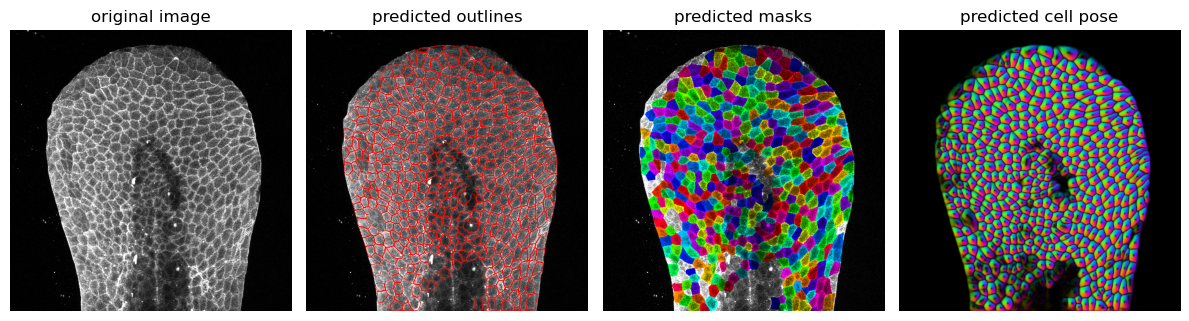

Saved mask and flow for image 0 → Total data/lat_trial2_beforedrug_elastic_output/cell_segmentation_work
Centroids saved → Total data/lat_trial2_beforedrug_elastic_output/cell_segmentation_work/centroids_0.csv


Total data/lat_trial2_beforedrug_elastic_output/cell_segmentation_work/mask_0.tiff is a low contrast image


In [3]:
if registration_type == "rigid":
    path_to_files = os.path.join(output_directory, "rigid_raw_registered")
elif registration_type == "elastic":
    path_to_files = os.path.join(output_directory, "elastic_membrane_raw")
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")


first_image = (
    f"raw_registered_{membrane_base_name}0000.tif"
    if registration_type == "rigid"
    else f"Registered_membrane_0000.tif"
)
files = [os.path.join(path_to_files, first_image)]

cell_segmentation_work = os.path.join(output_directory, "cell_segmentation_work")
os.makedirs(cell_segmentation_work, exist_ok=True)

cpio.logger_setup()
print(f"Processing file(s): {files}")

# load images (skimage for I/O)
imgs = [io.imread(f) for f in files]

channels = [[2, 0]]

try:
    # cellpose denoise model (cyto3 + deblur_cyto3)
    from cellpose.denoise import CellposeDenoiseModel
    model = CellposeDenoiseModel(
        gpu=True,
        model_type="cyto3",
        restore_type="deblur_cyto3",
    )
    print("[cellpose] Using DenoiseModel (cyto3 + deblur_cyto3).")
except Exception as e:
    print(f"[cellpose] DenoiseModel unavailable ({e}). Falling back to standard Cellpose.")
    from cellpose import models
    model = models.CellposeModel(gpu=True, model_type="cyto3")
    channels = [2, 0]

nimg = len(imgs)
print(f"Number of images: {nimg}")

# run segmentation
# Handle different return values from model.eval() depending on cellpose version
eval_result = model.eval(imgs, diameter=15, channels=channels)

# Check how many values were returned and unpack accordingly
if len(eval_result) == 4:
    masks, flows, styles, diams = eval_result
elif len(eval_result) == 3:
    masks, flows, styles = eval_result
    diams = None  # Diameters not returned in this version
    print("Note: model.eval() returned 3 values (masks, flows, styles). Diameters not available.")
elif len(eval_result) == 2:
    masks, flows = eval_result
    styles = None
    diams = None
    print("Note: model.eval() returned 2 values (masks, flows). Styles and diameters not available.")
else:
    raise ValueError(f"Unexpected number of return values from model.eval(): {len(eval_result)}")

for i in range(nimg):
    fig = plt.figure(figsize=(12, 5))
    plot.show_segmentation(fig, imgs[i], masks[i], flows[i][0], channels=channels)
    plt.tight_layout()
    plt.show()

    # save mask + flow
    mask_filename = os.path.join(cell_segmentation_work, f"mask_{i}.tiff")
    io.imsave(mask_filename, masks[i])  # ← CHANGED from skio.imsave

    flow_filename = os.path.join(cell_segmentation_work, f"flow_{i}.tiff")
    io.imsave(flow_filename, flows[i][0])  # ← CHANGED from skio.imsave

    print(f"Saved mask and flow for image {i} → {cell_segmentation_work}")

    # compute centroids
    labeled_mask = label(masks[i])
    props = regionprops(labeled_mask)

    centroid_csv_filename = os.path.join(cell_segmentation_work, f"centroids_{i}.csv")
    with open(centroid_csv_filename, mode="w", newline="") as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(["cell_number", "x_position", "y_position"])
        for j, region in enumerate(props):
            centroid = region.centroid
            writer.writerow([j + 1, centroid[1], centroid[0]])

    print(f"Centroids saved → {centroid_csv_filename}")

# Numbered Mask Overlay
# Registration GIF comparison Creation

In [11]:
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff")
output_numbered_mask = os.path.join(output_directory, "cell_segmentation_work", "mask_numbered.tiff")
mask = tifffile.imread(mask_path)
h, w = mask.shape
overlay_rgb = np.zeros((h, w, 3), dtype=np.uint8)
overlay_rgb[mask > 0] = [255, 0, 0]
boundaries = find_boundaries(mask, mode='outer')
overlay_rgb[boundaries] = [0,0,255]
overlay_img = Image.fromarray(overlay_rgb)
draw = ImageDraw.Draw(overlay_img)
try:
    font = ImageFont.truetype("arial.ttf", 8)
except IOError:
    font = ImageFont.load_default()
props = regionprops(mask)
for prop in props:
    y, x = prop.centroid
    text = str(prop.label)
    bbox = font.getbbox(text)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    draw.text((x - text_width/2, y - text_height/2), text, fill="yellow", font=font)
overlay_img.save(output_numbered_mask)
print(f"Numbered mask saved at: {output_numbered_mask}")


gif_output_path = os.path.join(output_directory, "comparison_animation.gif")
opacity_factor = 0.4
mask_opacity = 0.5

mask = tifffile.imread(mask_path)
mask_edges = cv2.Canny(mask.astype(np.uint8), 1, 255)
mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint16)
mask_rgb[mask_edges > 0] = [65535, 0, 0]

original_folder = os.path.join(input_root, "membrane")


if registration_type == "rigid":
    registered_membrane_folder = os.path.join(output_directory, "rigid_raw_registered")
    registered_calcium_folder = os.path.join(output_directory, "rigid_green_registered")
    reg_mem_prefix = f"raw_registered_{membrane_base_name}"
    reg_ca_prefix = f"registered_{calcium_base_name}"
elif registration_type == "elastic":
    registered_membrane_folder = os.path.join(output_directory, "elastic_membrane_norm")
    registered_calcium_folder = os.path.join(output_directory, "elastic_ca_norm")
    reg_mem_prefix = "Registered_membrane_"
    reg_ca_prefix = "Registered_CA_"
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")


first_original = tifffile.imread(os.path.join(original_folder, f"{membrane_base_name}0000.tif"))
first_registered = tifffile.imread(os.path.join(registered_membrane_folder, f"{reg_mem_prefix}0000.tif"))


def enhance_for_display(img):
    """Normalize to 0-255 and apply contrast enhancement"""
   
    img_norm = ((img - img.min()) / (img.max() - img.min()) * 65535).astype(np.uint16)
    
    img_bright = np.power(img_norm / 65535.0, 0.5) * 65535  
    return img_bright.astype(np.uint16)

first_original_enhanced = enhance_for_display(first_original)
first_registered_enhanced = enhance_for_display(first_registered)

first_original_rgb = np.stack([first_original_enhanced//4]*2 + [first_original_enhanced//2], axis=-1)
first_registered_rgb = np.stack([first_registered_enhanced//4]*2 + [first_registered_enhanced//2], axis=-1)

gif_frames = []
for frame in range(num_frames):
    print(frame)
    frame_str = f"{frame:04d}"
    orig_path = os.path.join(original_folder, f"{membrane_base_name}{frame_str}.tif")
    reg_mem_path = os.path.join(registered_membrane_folder, f"{reg_mem_prefix}{frame_str}.tif")
    reg_ca_path = os.path.join(registered_calcium_folder, f"{reg_ca_prefix}{frame_str}.tif")
    
    if not os.path.exists(orig_path) or not os.path.exists(reg_mem_path) or not os.path.exists(reg_ca_path):
        print(f"Skipping frame {frame_str}")
        continue
    
    # Load and enhance for visibility
    original = enhance_for_display(tifffile.imread(orig_path))
    reg_mem = enhance_for_display(tifffile.imread(reg_mem_path))
    reg_ca = enhance_for_display(tifffile.imread(reg_ca_path))
    
    orig_rgb = np.stack([original]*3, axis=-1)
    reg_mem_rgb = np.stack([reg_mem]*3, axis=-1)
    reg_ca_rgb = np.stack([reg_ca]*3, axis=-1)
    
    orig_combined = ((1 - opacity_factor) * orig_rgb + opacity_factor * first_original_rgb).astype(np.uint16)
    reg_mem_combined = ((1 - opacity_factor) * reg_mem_rgb + opacity_factor * first_registered_rgb).astype(np.uint16)
    reg_mem_with_mask = ((1 - mask_opacity) * reg_mem_rgb + mask_opacity * mask_rgb).astype(np.uint16)
    
    combined = np.hstack([orig_combined, reg_mem_combined, reg_mem_with_mask, reg_ca_rgb])
    img_pil = Image.fromarray((combined/256).astype(np.uint8))
    draw = ImageDraw.Draw(img_pil)
    
    titles = ["Original Membrane", "Registered Membrane", "Reg Membrane + Mask", "Registered Calcium"]
    for i, title in enumerate(titles):
        draw.text((i*original.shape[1] + 10, 10), title, fill="white")
    
    gif_frames.append(img_pil)

gif_frames[0].save(gif_output_path, save_all=True, append_images=gif_frames[1:], duration=100, loop=0)
print(f"✅ Brightened comparison GIF saved at: {gif_output_path}")

Numbered mask saved at: Total data/lat_trial2_beforedrug_elastic_output/cell_segmentation_work/mask_numbered.tiff
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
✅ Brightened comparison GIF saved at: Total data/lat_trial2_beforedrug_elastic_output/comparison_animation.gif


# Background Subtraction

click the code block and choose three areas where it is just the background


In [ ]:
import os
import numpy as np
import tifffile
import matplotlib
matplotlib.use('TkAgg') 
import matplotlib.pyplot as plt
from matplotlib.widgets import RectangleSelector
# matplotlib.use('TkAgg') 
if registration_type == "rigid":
    red_membrane_folder  = os.path.join(output_directory, "rigid_raw_registered")
    green_calcium_folder = os.path.join(output_directory, "rigid_green_registered")
    red_first_name       = f"raw_registered_{membrane_base_name}0000.tif"
    red_name_fmt         = lambda i: f"raw_registered_{membrane_base_name}{i:04d}.tif"
    green_name_fmt       = lambda i: f"registered_{calcium_base_name}{i:04d}.tif"
elif registration_type == "elastic":
    red_membrane_folder  = os.path.join(output_directory, "elastic_membrane_raw")
    green_calcium_folder = os.path.join(output_directory, "elastic_ca_raw")
    red_first_name       = "Registered_membrane_0000.tif"
    red_name_fmt         = lambda i: f"Registered_membrane_{i:04d}.tif"
    green_name_fmt       = lambda i: f"Registered_CA_{i:04d}.tif"
else:
    raise ValueError("registration_type must be 'rigid' or 'elastic'")

output_red_folder   = os.path.join(output_directory, "Bkrm_membrane")
output_green_folder = os.path.join(output_directory, "Bkrm_ca2")
os.makedirs(output_red_folder, exist_ok=True)
os.makedirs(output_green_folder, exist_ok=True)


first_red_path = os.path.join(red_membrane_folder, red_first_name)
if not os.path.exists(first_red_path):
    raise FileNotFoundError(f"First red frame not found: {first_red_path}")

first_red_image = tifffile.imread(first_red_path).astype(np.uint16)
rectangles = []

def on_select(eclick, erelease):
    x1, y1 = int(eclick.xdata), int(eclick.ydata)
    x2, y2 = int(erelease.xdata), int(erelease.ydata)
    rectangles.append((x1, y1, x2, y2))
    print(f"Selected region: ({x1}, {y1}) to ({x2}, {y2})")
    if len(rectangles) >= 3:
        plt.close()

fig, ax = plt.subplots()
ax.imshow(first_red_image, cmap="gray",
          vmin=int(first_red_image.min()),
          vmax=int(first_red_image.max()))
ax.set_title("Select 3 background regions (Drag to create rectangles)")
rect_selector = RectangleSelector(ax, on_select, interactive=True)
plt.show()


def remove_outliers(data):
    Q1, Q3 = np.percentile(data, [25, 75])
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data >= lower_bound) & (data <= upper_bound)]

for frame in range(num_frames):
    frame_str = f"{frame:04d}"

    red_path   = os.path.join(red_membrane_folder,  red_name_fmt(frame))
    green_path = os.path.join(green_calcium_folder, green_name_fmt(frame))

    if not os.path.exists(red_path) or not os.path.exists(green_path):
        print(f"Skipping frame {frame_str} (File missing)")
        continue

    red_image   = tifffile.imread(red_path).astype(np.uint16)
    green_image = tifffile.imread(green_path).astype(np.uint16)

    background_values_red = []
    background_values_green = []

    for (x1, y1, x2, y2) in rectangles:
        
        x1c, y1c = max(0, x1), max(0, y1)
        x2c, y2c = min(red_image.shape[1], x2), min(red_image.shape[0], y2)

        red_pixels   = red_image[y1c:y2c, x1c:x2c].flatten()
        green_pixels = green_image[y1c:y2c, x1c:x2c].flatten()

        clean_red_pixels   = remove_outliers(red_pixels)
        clean_green_pixels = remove_outliers(green_pixels)

        background_values_red.append(np.median(clean_red_pixels))
        background_values_green.append(np.median(clean_green_pixels))

    
    avg_bg_red   = np.median(background_values_red)
    avg_bg_green = np.median(background_values_green)

    red_corrected   = np.clip(red_image   - avg_bg_red,   0, 65535).astype(np.uint16)
    green_corrected = np.clip(green_image - avg_bg_green, 0, 65535).astype(np.uint16)

    tifffile.imwrite(os.path.join(output_red_folder,   f"processed_red_{frame_str}.tif"),   red_corrected)
    tifffile.imwrite(os.path.join(output_green_folder, f"processed_green_{frame_str}.tif"), green_corrected)

    print(f"Processed and saved frame {frame_str}")

print("Background subtraction complete for all frames!")
print("Membrane outputs →", output_red_folder)
print("Calcium outputs  →", output_green_folder)


invalid value encountered in cast
invalid value encountered in cast


Processed and saved frame 0000
Processed and saved frame 0001
Processed and saved frame 0002
Processed and saved frame 0003
Processed and saved frame 0004
Processed and saved frame 0005
Processed and saved frame 0006
Processed and saved frame 0007
Processed and saved frame 0008
Processed and saved frame 0009
Processed and saved frame 0010
Processed and saved frame 0011
Processed and saved frame 0012
Processed and saved frame 0013
Processed and saved frame 0014
Processed and saved frame 0015
Processed and saved frame 0016
Processed and saved frame 0017
Processed and saved frame 0018
Processed and saved frame 0019
Processed and saved frame 0020
Processed and saved frame 0021
Processed and saved frame 0022
Processed and saved frame 0023
Processed and saved frame 0024
Processed and saved frame 0025
Processed and saved frame 0026
Processed and saved frame 0027
Processed and saved frame 0028
Processed and saved frame 0029
Processed and saved frame 0030
Background subtraction complete for all

: 

In [ ]:
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff")
output_numbered_mask = os.path.join(output_directory, "cell_segmentation_work", "mask_numbered.tiff")
mask = tifffile.imread(mask_path)
h, w = mask.shape
overlay_rgb = np.zeros((h, w, 3), dtype=np.uint8)
overlay_rgb[mask > 0] = [255, 0, 0]
boundaries = find_boundaries(mask, mode='outer')
overlay_rgb[boundaries] = [0,0,255]
overlay_img = Image.fromarray(overlay_rgb)
draw = ImageDraw.Draw(overlay_img)
try:
    font = ImageFont.truetype("arial.ttf", 8)
except IOError:
    font = ImageFont.load_default()
props = regionprops(mask)
for prop in props:
    y, x = prop.centroid
    text = str(prop.label)
    bbox = font.getbbox(text)
    text_width = bbox[2] - bbox[0]
    text_height = bbox[3] - bbox[1]
    draw.text((x - text_width/2, y - text_height/2), text, fill="yellow", font=font)
overlay_img.save(output_numbered_mask)
print(f"Numbered mask saved at: {output_numbered_mask}")

# === BRIGHTENED GIF Creation ===
gif_output_path = os.path.join(output_directory, "comparison_animation.gif")
opacity_factor = 0.4
mask_opacity = 0.5

mask = tifffile.imread(mask_path)
mask_edges = cv2.Canny(mask.astype(np.uint8), 1, 255)
mask_rgb = np.zeros((*mask.shape, 3), dtype=np.uint16)
mask_rgb[mask_edges > 0] = [65535, 0, 0]

original_folder = os.path.join(input_root, "membrane")

# ✅ USE BACKGROUND-SUBTRACTED IMAGES
registered_membrane_folder = os.path.join(output_directory, "Bkrm_membrane")
registered_calcium_folder = os.path.join(output_directory, "Bkrm_ca2")

# Load first frames
first_original = tifffile.imread(os.path.join(original_folder, f"{membrane_base_name}0000.tif"))
first_registered = tifffile.imread(os.path.join(registered_membrane_folder, "processed_red_0000.tif"))

# ✅ BRIGHTNESS FIX: Normalize and enhance contrast
def enhance_for_display(img):
    """Normalize to 0-255 and apply contrast enhancement"""
    # Normalize to 0-65535 range
    img_norm = ((img - img.min()) / (img.max() - img.min()) * 65535).astype(np.uint16)
    # Boost mid-tones for better visibility (apply gamma correction)
    img_bright = np.power(img_norm / 65535.0, 0.5) * 65535  # Gamma = 0.5 brightens
    return img_bright.astype(np.uint16)

first_original_enhanced = enhance_for_display(first_original)
first_registered_enhanced = enhance_for_display(first_registered)

first_original_rgb = np.stack([first_original_enhanced//4]*2 + [first_original_enhanced//2], axis=-1)
first_registered_rgb = np.stack([first_registered_enhanced//4]*2 + [first_registered_enhanced//2], axis=-1)

gif_frames = []
for frame in range(num_frames):
    print(frame)
    frame_str = f"{frame:04d}"
    orig_path = os.path.join(original_folder, f"{membrane_base_name}{frame_str}.tif")
    reg_mem_path = os.path.join(registered_membrane_folder, f"processed_red_{frame_str}.tif")
    reg_ca_path = os.path.join(registered_calcium_folder, f"processed_green_{frame_str}.tif")
    
    if not os.path.exists(orig_path) or not os.path.exists(reg_mem_path) or not os.path.exists(reg_ca_path):
        print(f"Skipping frame {frame_str}")
        continue
    
    # Load and enhance for visibility
    original = enhance_for_display(tifffile.imread(orig_path))
    reg_mem = enhance_for_display(tifffile.imread(reg_mem_path))
    reg_ca = enhance_for_display(tifffile.imread(reg_ca_path))
    
    orig_rgb = np.stack([original]*3, axis=-1)
    reg_mem_rgb = np.stack([reg_mem]*3, axis=-1)
    reg_ca_rgb = np.stack([reg_ca]*3, axis=-1)
    
    orig_combined = ((1 - opacity_factor) * orig_rgb + opacity_factor * first_original_rgb).astype(np.uint16)
    reg_mem_combined = ((1 - opacity_factor) * reg_mem_rgb + opacity_factor * first_registered_rgb).astype(np.uint16)
    reg_mem_with_mask = ((1 - mask_opacity) * reg_mem_rgb + mask_opacity * mask_rgb).astype(np.uint16)
    
    combined = np.hstack([orig_combined, reg_mem_combined, reg_mem_with_mask, reg_ca_rgb])
    img_pil = Image.fromarray((combined/256).astype(np.uint8))
    draw = ImageDraw.Draw(img_pil)
    
    titles = ["Original Membrane", "Registered Membrane", "Reg Membrane + Mask", "Registered Calcium"]
    for i, title in enumerate(titles):
        draw.text((i*original.shape[1] + 10, 10), title, fill="white")
    
    gif_frames.append(img_pil)

gif_frames[0].save(gif_output_path, save_all=True, append_images=gif_frames[1:], duration=100, loop=0)
print(f"✅ Brightened comparison GIF saved at: {gif_output_path}")

# Part 3: Calcium Analysis

Run this code to find the max, average and sum intensities of caclium for each cell in each frame
This will output a csv with the information ('cell_number', 'frame', 'max_intensity', 'avg_intensity', 'sum_intensity') and a png graph for each cell plotting the Max, Avg, and Sum calcium vs frame number

In [ ]:
import matplotlib
matplotlib.use("Agg")  # Non-interactive backend

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageDraw, ImageFont
import os
import tifffile

# Paths based on your current workflow
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff")
ca_dir = os.path.join(output_directory, "Bkrm_ca2")  # Background-subtracted calcium
output_dir_raw = os.path.join(output_directory, "calcium_analysis", "raw_graphs")
output_dir_norm = os.path.join(output_directory, "calcium_analysis", "normalized_graphs")
output_dir_data = os.path.join(output_directory, "calcium_analysis", "data")
output_dir_diagnostic = os.path.join(output_directory, "calcium_analysis", "diagnostics")

ca_prefix = "processed_green_"
ca_extension = ".tif"

# Create output directories
os.makedirs(output_dir_raw, exist_ok=True)
os.makedirs(output_dir_norm, exist_ok=True)
os.makedirs(output_dir_data, exist_ok=True)
os.makedirs(output_dir_diagnostic, exist_ok=True)

print("Loading mask and extracting calcium intensities...")

# Load the mask
mask = tifffile.imread(mask_path)
cell_ids = np.unique(mask)
cell_ids = cell_ids[cell_ids > 0]  # Exclude background

print(f"Found {len(cell_ids)} cells")

# Dictionary to store calcium intensities for each cell
cell_intensities = {cell_id: [] for cell_id in cell_ids}

# Process each calcium image
for frame in range(num_frames):
    frame_str = f"{frame:04d}"
    ca_path = os.path.join(ca_dir, f"{ca_prefix}{frame_str}{ca_extension}")
    
    if not os.path.exists(ca_path):
        print(f"Warning: Frame {frame_str} not found, filling with NaN")
        for cell_id in cell_ids:
            cell_intensities[cell_id].append(np.nan)
        continue

    ca_image = tifffile.imread(ca_path)

    for cell_id in cell_ids:
        cell_pixels = ca_image[mask == cell_id]
        avg_intensity = np.mean(cell_pixels) if cell_pixels.size > 0 else 0
        cell_intensities[cell_id].append(avg_intensity)

print("✓ Intensity extraction complete")

# ========== BASELINE SELECTION ==========
print("\n" + "="*60)
print("BASELINE (F0) SELECTION")
print("="*60)

# Create diagnostic plot to help choose baseline
frame_avg = [np.nanmean([cell_intensities[cid][f] for cid in cell_ids]) for f in range(num_frames)]

plt.figure(figsize=(12, 5))
plt.plot(frame_avg, marker='o', linewidth=2, markersize=4)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Average Calcium Intensity (all cells)', fontsize=12)
plt.title('Population Average - Identify Baseline Frames', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.axhline(np.min(frame_avg), color='green', linestyle='--', alpha=0.5, label=f'Min = {np.min(frame_avg):.1f}')
plt.axhline(np.max(frame_avg), color='red', linestyle='--', alpha=0.5, label=f'Max = {np.max(frame_avg):.1f}')
plt.legend()
diagnostic_plot = os.path.join(output_dir_diagnostic, "population_average_for_baseline_selection.png")
plt.savefig(diagnostic_plot, dpi=150, bbox_inches='tight')
plt.close()

print(f"✓ Diagnostic plot saved: {diagnostic_plot}")
print("\nPopulation statistics:")
print(f"  Frame with min avg: {np.argmin(frame_avg)} (intensity: {np.min(frame_avg):.1f})")
print(f"  Frame with max avg: {np.argmax(frame_avg)} (intensity: {np.max(frame_avg):.1f})")
print(f"  Mean across all frames: {np.mean(frame_avg):.1f}")

# ========== CHOOSE BASELINE METHOD ==========
print("\n" + "-"*60)
print("BASELINE METHOD OPTIONS:")
print("  1 = First N frames (default: frames 0-9)")
print("  2 = Last N frames (default: last 10 frames)")
print("  3 = Frames with LOWEST activity (automatic - RECOMMENDED)")
print("  4 = Manual frame range (specify below)")
print("-"*60)

# ⚙️ CONFIGURE BASELINE HERE:
baseline_method = 3  # ← CHANGE THIS: 1, 2, 3, or 4
baseline_frames_count = 10  # How many frames to use for baseline
manual_baseline_frames = None  # For method 4: e.g., range(15, 25)

if baseline_method == 1:
    baseline_frames = list(range(min(baseline_frames_count, num_frames)))
    print(f"✓ Using FIRST {len(baseline_frames)} frames as baseline")
    
elif baseline_method == 2:
    baseline_frames = list(range(max(0, num_frames - baseline_frames_count), num_frames))
    print(f"✓ Using LAST {len(baseline_frames)} frames as baseline")
    
elif baseline_method == 3:
    # Find frames with lowest population average (most likely resting state)
    sorted_frames = sorted(range(num_frames), key=lambda f: frame_avg[f])
    baseline_frames = sorted(sorted_frames[:baseline_frames_count])
    print(f"✓ Using {baseline_frames_count} frames with LOWEST activity as baseline")
    print(f"  Selected frames: {baseline_frames}")
    print(f"  Average intensity in baseline: {np.mean([frame_avg[f] for f in baseline_frames]):.1f}")
    
elif baseline_method == 4:
    if manual_baseline_frames is None:
        raise ValueError("Please specify manual_baseline_frames (e.g., range(15, 25))")
    baseline_frames = list(manual_baseline_frames)
    print(f"✓ Using MANUAL baseline frames: {baseline_frames}")

else:
    raise ValueError("baseline_method must be 1, 2, 3, or 4")

print("="*60 + "\n")

# ========== COMPUTE F0 AND NORMALIZE ==========
print("Computing normalized traces (ΔF/F0)...")

# Compute baseline intensity (F0) for each cell
cell_f0 = {}
for cell_id, intensities in cell_intensities.items():
    baseline_values = [intensities[f] for f in baseline_frames if f < len(intensities)]
    f0 = np.nanmean(baseline_values)
    cell_f0[cell_id] = f0 if f0 > 0 else 1  # Avoid division by zero
    
    # Debug first few cells
    if cell_id <= 3:
        print(f"  Cell {cell_id}: F0 = {f0:.2f} (avg of frames {baseline_frames})")

# Normalize using ΔF/F0: (Ft - F0) / F0
cell_intensities_normalized = {
    cell_id: [(F - cell_f0[cell_id]) / cell_f0[cell_id] if not np.isnan(F) else np.nan for F in intensities]
    for cell_id, intensities in cell_intensities.items()
}

# Check if normalization looks reasonable
sample_cell = cell_ids[0]
norm_values = [v for v in cell_intensities_normalized[sample_cell] if not np.isnan(v)]
print(f"\n✓ Normalization complete!")
print(f"  Sample (Cell {sample_cell}):")
print(f"    ΔF/F0 range: [{min(norm_values):.2f}, {max(norm_values):.2f}]")
print(f"    Mean ΔF/F0: {np.mean(norm_values):.2f}")

if max(norm_values) < 0.5:
    print("\n⚠️  WARNING: All normalized values are low. This might indicate:")
    print("    - Wrong baseline frames selected")
    print("    - Very weak calcium signals")
    print("    Check the diagnostic plot!")

# ========== SAVE DATA ==========
print("\nSaving individual cell CSVs and graphs...")

# Save per-cell raw and normalized CSVs and graphs
for cell_id in cell_ids:
    # Individual CSVs
    df_raw = pd.DataFrame({"Frame": range(num_frames), "Avg Intensity": cell_intensities[cell_id]})
    df_raw.to_csv(os.path.join(output_dir_data, f"cell_{cell_id}_raw.csv"), index=False)

    df_norm = pd.DataFrame({"Frame": range(num_frames), "Normalized Intensity (ΔF/F0)": cell_intensities_normalized[cell_id]})
    df_norm.to_csv(os.path.join(output_dir_data, f"cell_{cell_id}_normalized.csv"), index=False)

    # Combined graph (raw + normalized)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
    
    # Raw trace
    ax1.plot(range(num_frames), cell_intensities[cell_id], color="blue", linewidth=2)
    ax1.axhline(cell_f0[cell_id], color='red', linestyle='--', linewidth=2, alpha=0.7, label=f'F0 = {cell_f0[cell_id]:.1f}')
    for f in baseline_frames:
        ax1.axvspan(f-0.5, f+0.5, alpha=0.15, color='yellow')
    ax1.set_ylabel("Fluorescence Intensity", fontsize=11)
    ax1.set_title(f"Cell {cell_id} - Raw Calcium Trace", fontsize=12, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    
    # Normalized trace
    ax2.plot(range(num_frames), cell_intensities_normalized[cell_id], color="red", linewidth=2)
    ax2.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    for f in baseline_frames:
        ax2.axvspan(f-0.5, f+0.5, alpha=0.15, color='yellow')
    ax2.set_xlabel("Frame", fontsize=11)
    ax2.set_ylabel("ΔF/F0", fontsize=11)
    ax2.set_title(f"Cell {cell_id} - Normalized (ΔF/F0)", fontsize=12, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir_raw, f"cell_{cell_id}_traces.png"), dpi=150, bbox_inches='tight')
    plt.close()

print(f"✓ Individual cell graphs saved to: {output_dir_raw}")

print("\nCreating matrix-style CSVs (all cells)...")

# MATRIX CSV: All cells RAW intensities
df_raw_matrix = pd.DataFrame({f"Cell_{cell_id}": cell_intensities[cell_id] for cell_id in cell_ids})
df_raw_matrix.insert(0, "Frame", list(range(num_frames)))
df_raw_matrix.to_csv(os.path.join(output_dir_data, "all_cells_raw.csv"), index=False)
print(f"✓ All cells RAW matrix: all_cells_raw.csv")

# MATRIX CSV: All cells NORMALIZED intensities
df_norm_matrix = pd.DataFrame({f"Cell_{cell_id}": cell_intensities_normalized[cell_id] for cell_id in cell_ids})
df_norm_matrix.insert(0, "Frame", list(range(num_frames)))
df_norm_matrix.to_csv(os.path.join(output_dir_data, "all_cells_normalized.csv"), index=False)
print(f"✓ All cells NORMALIZED matrix: all_cells_normalized.csv")

# Combined data (both raw and normalized in one file)
combined_data = {"Frame": list(range(num_frames))}
for cell_id in cell_ids:
    combined_data[f"Cell_{cell_id}_Raw"] = cell_intensities[cell_id]
    combined_data[f"Cell_{cell_id}_Norm"] = cell_intensities_normalized[cell_id]

df_combined = pd.DataFrame(combined_data)
df_combined.to_csv(os.path.join(output_dir_data, "all_cells_data.csv"), index=False)
print(f"✓ Combined (raw + normalized): all_cells_data.csv")

print(f"\n" + "="*60)
print("✅ ANALYSIS COMPLETE!")
print("="*60)
print(f"Output locations:")
print(f"  📊 Data CSVs: {output_dir_data}")
print(f"  📈 Graphs: {output_dir_raw}")
print(f"  🔍 Diagnostics: {output_dir_diagnostic}")
print(f"\n💡 Check '{diagnostic_plot}' to verify baseline selection!")
print("="*60)

In [ ]:
import numpy as np
import os
from PIL import Image
import matplotlib.pyplot as plt

try:
    from matplotlib.widgets import RectangleSelector
except Exception:
    RectangleSelector = None

# Define the required variables
ca_dir = os.path.join(output_directory, "Bkrm_ca2") 
ca_prefix = "processed_green_" 
ca_extension = ".tif"  
mask_path = os.path.join(output_directory, "cell_segmentation_work", "mask_0.tiff") 
mask = io.imread(mask_path)
def _enable_interactive_backend():
    try:
        plt.switch_backend("TkAgg")
        return True
    except Exception:
        try:
            plt.switch_backend("Qt5Agg")
            return True
        except Exception:
            return False


try:
    from matplotlib.widgets import RectangleSelector
except Exception:
    RectangleSelector = None


def _enable_interactive_backend():
    try:
        
        plt.switch_backend("TkAgg")
        return True
    except Exception:
        try:
            plt.switch_backend("Qt5Agg")
            return True
        except Exception:
            return False


_first_frame_path = os.path.join(
    ca_dir,
    f"{ca_prefix}{0:04d}{ca_extension}"
)

_display_img = None
if os.path.exists(_first_frame_path):
    try:
        _display_img = np.array(Image.open(_first_frame_path))
    except Exception:
        _display_img = None

if _display_img is None:

    _display_img = np.array(Image.open(mask_path))

_rect = [None]  

def _on_select(eclick, erelease):
    x1, y1 = int(round(eclick.xdata)), int(round(eclick.ydata))
    x2, y2 = int(round(erelease.xdata)), int(round(erelease.ydata))
    x_min, x_max = sorted([x1, x2])
    y_min, y_max = sorted([y1, y2])
    _rect[0] = (x_min, y_min, x_max, y_max)
    print(f"[ROI] Selected region: (x={x_min}, y={y_min}) → (x={x_max}, y={y_max})")
    plt.close()

_do_interactive = RectangleSelector is not None and _enable_interactive_backend()

if _do_interactive:
    fig, ax = plt.subplots()
    ax.imshow(_display_img, cmap="gray")
    ax.set_title("Select ONE ROI (drag a rectangle), then release mouse")
    rect_selector = RectangleSelector(ax, _on_select, interactive=True)
    plt.show()
else:
    print("[ROI] Interactive selection unavailable (backend or widgets missing). "
          "To enable, run an interactive backend (e.g., `%matplotlib widget`), "
          "or remove the `Agg` backend earlier, then re-run this ROI cell.")


if _rect[0] is not None:
    x1, y1, x2, y2 = _rect[0]
 
    H, W = mask.shape[:2]
    x1 = max(0, min(W - 1, x1)); x2 = max(0, min(W, x2))
    y1 = max(0, min(H - 1, y1)); y2 = max(0, min(H, y2))

    roi_slice = mask[y1:y2, x1:x2]
    roi_cell_ids = np.unique(roi_slice)
    roi_cell_ids = roi_cell_ids[roi_cell_ids > 0]

    if roi_cell_ids.size == 0:
        print("[ROI] No labeled cells found in the selected region. No ROI CSVs written.")
    else:
        print(f"[ROI] {roi_cell_ids.size} cell(s) in ROI → {roi_cell_ids.tolist()}")

        
        for cid in roi_cell_ids:
            # Raw
            df_raw_roi = pd.DataFrame({
                "Frame": range(len(cell_intensities[cid])),
                "Avg Intensity": cell_intensities[cid]
            })
            df_raw_roi.to_csv(
                os.path.join(output_dir_data, f"cell_{cid}_raw_roi.csv"),
                index=False
            )

            
            df_norm_roi = pd.DataFrame({
                "Frame": range(len(cell_intensities_normalized[cid])),
                "Normalized Intensity (ΔF/F0)": cell_intensities_normalized[cid]
            })
            df_norm_roi.to_csv(
                os.path.join(output_dir_data, f"cell_{cid}_normalized_roi.csv"),
                index=False
            )

     
        roi_combined = {"Frame": list(range(num_frames))}
        for cid in roi_cell_ids:
            roi_combined[f"Cell_{cid}_Raw"]  = cell_intensities[cid]
            roi_combined[f"Cell_{cid}_Norm"] = cell_intensities_normalized[cid]
        df_roi_combined = pd.DataFrame(roi_combined)
        df_roi_combined.to_csv(
            os.path.join(output_dir_data, "roi_cells_data.csv"),
            index=False
        )

        df_roi_raw = pd.DataFrame({f"Cell_{cid}": cell_intensities[cid] for cid in roi_cell_ids})
        df_roi_raw.insert(0, "Frame", list(range(num_frames)))
        df_roi_raw.to_csv(
            os.path.join(output_dir_data, "roi_cells_raw.csv"),
            index=False
        )

        df_roi_norm = pd.DataFrame({f"Cell_{cid}": cell_intensities_normalized[cid] for cid in roi_cell_ids})
        df_roi_norm.insert(0, "Frame", list(range(num_frames)))
        df_roi_norm.to_csv(
            os.path.join(output_dir_data, "roi_cells_normalized.csv"),
            index=False
        )

        print("[ROI] ROI-only CSVs written:",
              os.path.join(output_dir_data, "roi_cells_data.csv"), ", ",
              os.path.join(output_dir_data, "roi_cells_raw.csv"), ", ",
              os.path.join(output_dir_data, "roi_cells_normalized.csv"))
else:
    print("[ROI] Skipped ROI export (no rectangle selected).")


In [ ]:
# ============================================================
# PART 4: CALCIUM SIGNAL PEAK ANALYSIS
# ============================================================

import matplotlib
matplotlib.use('Agg')  # Prevent popup windows

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
import pandas as pd

def analyze_ca_signal(time, signal, threshold):
    """
    Analyze a single-cell Ca2+ signal to find:
    1) The peaks above a given threshold
    2) Time of the first peak
    3) Durations between consecutive peaks
    4) Area under each peak (above the threshold)
    
    Parameters
    ----------
    time : array-like
        1D array of time points.
    signal : array-like
        1D array of Ca2+ intensity (same length as time).
    threshold : float
        Minimum height a peak must have to be counted.
    
    Returns
    -------
    peak_indices : np.array
        Indices of all detected peaks in 'signal' that exceed 'threshold'.
    peak_times : np.array
        Corresponding time values at each peak.
    time_to_first_peak : float or None
        Time of the first peak, or None if no peaks.
    peak_intervals : np.array
        Durations (in the same time units) between consecutive peaks.
    peak_areas : np.array
        Estimated areas under each peak, above 'threshold'. 
        (Same units as signal * time.)
    """
    time = np.asarray(time)
    signal = np.asarray(signal)

    if len(time) != len(signal):
        raise ValueError("time and signal must have the same length.")

    # Use find_peaks to find peaks above the threshold
    peak_indices, _ = find_peaks(signal, height=threshold)

    # Filter out peaks to ensure signal value > threshold (redundant if 'height=threshold' is used)
    valid_peaks = peak_indices[signal[peak_indices] >= threshold]

    if len(valid_peaks) == 0:
        # No peaks found
        return np.array([]), np.array([]), None, np.array([]), np.array([]), []

    # Time to first peak
    time_to_first_peak = time[valid_peaks[0]]

    # Durations between consecutive peaks
    peak_times = time[valid_peaks]
    peak_intervals = np.diff(peak_times)

    # Calculate areas under each peak above the threshold
    peak_areas = []
    left_right_bounds = []
    for idx in valid_peaks:
        left_idx = idx
        while left_idx > 0 and signal[left_idx] > threshold:
            left_idx -= 1
        
        right_idx = idx
        while right_idx < len(signal) - 1 and signal[right_idx] > threshold:
            right_idx += 1
        
        left_right_bounds.append((left_idx, right_idx))
        
        region_time = time[left_idx : right_idx + 1]
        region_signal = signal[left_idx : right_idx + 1]
        above_threshold = np.clip(region_signal - threshold, 0, None)
        area = np.trapz(above_threshold, region_time)
        peak_areas.append(area)
    
    return valid_peaks, peak_times, time_to_first_peak, peak_intervals, np.array(peak_areas), left_right_bounds

def normalize_signal(signal):
    """
    Normalize the signal by the formula:
        (signal - min(signal)) / min(signal)
        
    Parameters
    ----------
    signal : array-like
        The 1D signal to be normalized.
        
    Returns
    -------
    normalized_signal : np.ndarray
        The normalized signal.
    """
    signal = np.asarray(signal)
    min_val = np.min(signal)
    
    # Be cautious if min_val <= 0 -- might lead to division by zero or negative division.
    if min_val <= 1:
        # raise ValueError("Cannot normalize as defined when min(signal) <= 0.")
        min_val = 1.0  # prevent division by zero
    normalized_signal = (signal - min_val) / min_val
    return normalized_signal

print("✅ Analysis functions defined")

# ============================================================
# PEAK DETECTION AND ANALYSIS
# ============================================================
# Analyze each cell's calcium signal to detect peaks and calculate statistics

# Lists to store data from all cells
all_peak_intervals = []
all_peak_areas = []
all_peak_times = []

# Read the ROI data generated from the previous step
roi_csv_path = os.path.join(output_directory, "calcium_analysis", "data", "roi_cells_normalized.csv")
df = pd.read_csv(roi_csv_path)
print("Data shape:", df.shape)

# Set a threshold
threshold = 0

# Create output directory for individual cell plots
peak_plots_dir = os.path.join(output_directory, "calcium_analysis", "peak_plots")
os.makedirs(peak_plots_dir, exist_ok=True)

for i in range(df.shape[1]-1):  # Assuming first column is 'Frame' or time
    signal = df.iloc[:,i+1]  # Skip the 'Frame' column and get the i-th cell signal
    # signal = normalize_signal(signal)
    
    N = len(signal)      # number of points
    final_time = 90.0    # for example, 90 seconds
    
    # Create a time vector from 0 to final_time (inclusive), with N points
    time = np.linspace(0, final_time, N)
    
    # --- PLOTTING ---
    plt.figure()
    plt.plot(time, signal, label="Signal")
    plt.axhline(y=threshold, label="Threshold")
    
    # Analyze
    (peak_indices, peak_times, time_to_first_peak, peak_intervals, peak_areas, bounds) = analyze_ca_signal(time, signal, threshold)
    
    # Store the data for this cell
    if len(peak_intervals) > 0:
        all_peak_intervals.extend(peak_intervals)
    if len(peak_areas) > 0:
        all_peak_areas.extend(peak_areas)
    if len(peak_times) > 0:
        all_peak_times.extend(peak_times)
    
    # --- Print the result for each cell -----
    print(f"\nCell {i+1} results:")
    print("Detected peak indices:", peak_indices)
    print("Detected peak times:", peak_times)
    print("Time to first peak:", time_to_first_peak)
    print("Durations between peaks:", peak_intervals)
    print("Areas under each peak:", peak_areas)

    # Mark the peaks
    plt.plot(time[peak_indices], signal[peak_indices], "o", label="Detected Peaks")

    # Shade the area under each peak above the threshold
    for left_idx, right_idx in bounds:
        region_time = time[left_idx : right_idx + 1]
        region_signal = signal[left_idx : right_idx + 1]
        # We only fill above threshold
        plt.fill_between(
            region_time,
            threshold,  
            region_signal,
            where=(region_signal > threshold),
            alpha=0.3,  
        )

    plt.xlabel("Time")
    plt.ylabel("Signal Intensity")
    plt.title(f"Ca2+ Signal with Detected Peaks and Shaded Areas - Cell {i+1}")
    plt.legend()
    
    # Save plot instead of showing
    plt.savefig(os.path.join(peak_plots_dir, f"cell_{i+1}_peaks.png"), dpi=150, bbox_inches='tight')
    plt.close()

# Convert lists to numpy arrays for the statistical analysis
all_peak_intervals = np.array(all_peak_intervals)
all_peak_areas = np.array(all_peak_areas)
all_peak_times = np.array(all_peak_times)

print("\nCollected data from all cells:")
print(f"Total number of peak intervals: {len(all_peak_intervals)}")
print(f"Total number of peak areas: {len(all_peak_areas)}")
print(f"Total number of peak times: {len(all_peak_times)}")
print(f"\n✅ Individual cell peak plots saved to: {peak_plots_dir}")

# ============================================================
# STATISTICAL ANALYSIS AND SUMMARY PLOTS
# ============================================================
# Create violin plots showing distributions of peak characteristics

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calculate statistics for peak intervals
peak_intervals_mean = np.mean(all_peak_intervals)
peak_intervals_median = np.median(all_peak_intervals)
peak_intervals_std = np.std(all_peak_intervals)
peak_intervals_range = np.ptp(all_peak_intervals)

# Calculate statistics for peak areas
peak_areas_mean = np.mean(all_peak_areas)
peak_areas_median = np.median(all_peak_areas)
peak_areas_std = np.std(all_peak_areas)
peak_areas_range = np.ptp(all_peak_areas)

# Calculate statistics for peak times
peak_times_mean = np.mean(all_peak_times)
peak_times_median = np.median(all_peak_times)
peak_times_std = np.std(all_peak_times)
peak_times_range = np.ptp(all_peak_times)

# Print the statistics
print("\n" + "="*60)
print("PEAK ANALYSIS STATISTICS (ALL CELLS)")
print("="*60)
print("\nPeak Intervals Statistics (across all cells):")
print(f"Mean: {peak_intervals_mean:.2f}, Median: {peak_intervals_median:.2f}")
print(f"Std: {peak_intervals_std:.2f}, Range: {peak_intervals_range:.2f}")

print("\nPeak Areas Statistics (across all cells):")
print(f"Mean: {peak_areas_mean:.2f}, Median: {peak_areas_median:.2f}")
print(f"Std: {peak_areas_std:.2f}, Range: {peak_areas_range:.2f}")

In [ ]:
# ============================================================
# STATISTICAL ANALYSIS AND SUMMARY PLOTS
# ============================================================
# Create violin plots showing distributions of peak characteristics

import numpy as np
import matplotlib.pyplot as plt

# Create figure and subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Calculate statistics for peak intervals
peak_intervals_mean = np.mean(all_peak_intervals)
peak_intervals_median = np.median(all_peak_intervals)
peak_intervals_std = np.std(all_peak_intervals)
peak_intervals_range = np.ptp(all_peak_intervals)

# Calculate statistics for peak areas
peak_areas_mean = np.mean(all_peak_areas)
peak_areas_median = np.median(all_peak_areas)
peak_areas_std = np.std(all_peak_areas)
peak_areas_range = np.ptp(all_peak_areas)

# Calculate statistics for peak times
peak_times_mean = np.mean(all_peak_times)
peak_times_median = np.median(all_peak_times)
peak_times_std = np.std(all_peak_times)
peak_times_range = np.ptp(all_peak_times)

# Print the statistics
print("Peak Intervals Statistics (across all cells):")
print(f"Mean: {peak_intervals_mean:.2f}, Median: {peak_intervals_median:.2f}")
print(f"Std: {peak_intervals_std:.2f}, Range: {peak_intervals_range:.2f}")

print("\nPeak Areas Statistics (across all cells):")
print(f"Mean: {peak_areas_mean:.2f}, Median: {peak_areas_median:.2f}")
print(f"Std: {peak_areas_std:.2f}, Range: {peak_areas_range:.2f}")

print("\nPeak Times Statistics (across all cells):")
print(f"Mean: {peak_times_mean:.2f}, Median: {peak_times_median:.2f}")
print(f"Std: {peak_times_std:.2f}, Range: {peak_times_range:.2f}")

# Violin plot with scatter for peak intervals
ax1.violinplot(all_peak_intervals)
# Add scatter points with jitter
y = all_peak_intervals
x = np.random.normal(1, 0.05, size=len(y))  # Add jitter to x-position
ax1.scatter(x, y, alpha=0.5, c='blue', s=20)
ax1.set_title('Peak Intervals Distribution\n(All Cells)')
ax1.set_ylabel('Time')
ax1.axhline(y=peak_intervals_mean, color='r', linestyle='--', label=f'Mean: {peak_intervals_mean:.2f}')
ax1.legend()

# Violin plot with scatter for peak areas
ax2.violinplot(all_peak_areas)
# Add scatter points with jitter
y = all_peak_areas
x = np.random.normal(1, 0.05, size=len(y))
ax2.scatter(x, y, alpha=0.5, c='blue', s=20)
ax2.set_title('Peak Areas Distribution\n(All Cells)')
ax2.set_ylabel('Area')
ax2.axhline(y=peak_areas_mean, color='r', linestyle='--', label=f'Mean: {peak_areas_mean:.2f}')
ax2.legend()

# Violin plot with scatter for peak times
ax3.violinplot(all_peak_times)
# Add scatter points with jitter
y = all_peak_times
x = np.random.normal(1, 0.05, size=len(y))
ax3.scatter(x, y, alpha=0.5, c='blue', s=20)
ax3.set_title('Peak Times Distribution\n(All Cells)')
ax3.set_ylabel('Time')
ax3.axhline(y=peak_times_mean, color='r', linestyle='--', label=f'Mean: {peak_times_mean:.2f}')
ax3.legend()

plt.tight_layout()
plt.show()

# Print the number of peaks analyzed
print(f"\nTotal number of peaks analyzed across all cells:")
print(f"Number of peak intervals: {len(all_peak_intervals)}")
print(f"Number of peak areas: {len(all_peak_areas)}")
print(f"Number of peak times: {len(all_peak_times)}")

In [ ]:

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

calcium_threshold = 2.5  
outlier_threshold = 0.01 


graph_output_dir = os.path.join(output_directory, "calcium_analysis", "graphs")
os.makedirs(graph_output_dir, exist_ok=True)

normalized_csv = os.path.join(output_directory, "calcium_analysis", "data", "all_cells_normalized.csv")
df_norm = pd.read_csv(normalized_csv)


cell_names = [c for c in df_norm.columns if c.startswith("Cell_")]
frame_numbers = df_norm["Frame"].values
valid_cells = []

for cell_name in cell_names:
    trace = df_norm[cell_name].values
    if not (np.allclose(trace, 0, atol=outlier_threshold) or np.allclose(trace, 1, atol=outlier_threshold)):
        valid_cells.append(cell_name)

print(f"Total valid cells: {len(valid_cells)}")


ratios = []
for frame_idx in range(len(frame_numbers)):
    activated = sum(df_norm[cell][frame_idx] > calcium_threshold for cell in valid_cells)
    ratio = activated / len(valid_cells) if valid_cells else 0
    ratios.append(ratio)


plt.figure(figsize=(10, 6))
plt.plot(frame_numbers, ratios, marker='o', linestyle='-', color='b', label=f'Threshold = {calcium_threshold}')

plt.title('Fraction of Cells Above Calcium Threshold (ΔF/F0)')
plt.xlabel('Frames')
plt.ylabel('Activated Cells / Valid Cells')
plt.ylim(0, 1)
plt.grid(True)

plt.text(0.95 * max(frame_numbers), 0.9, f'Threshold = {calcium_threshold}', ha='right')

graph_filename = os.path.join(graph_output_dir, 'ratio_of_cells_above_threshold.png')
plt.savefig(graph_filename, dpi=300)
plt.close()

print(f"Population activity graph saved: {graph_filename}")
